# Example: Let's do an Out-of-Sample (OOS) Single Asset Simulation
In this example, we perform out-of-sample simulations of a single asset's share price using the geometric Brownian motion (GBM) model. Out-of-sample testing means evaluating the model on data __not used during parameter estimation__. We use the mean growth rate and volatility estimated from the 2014 to 2024 training data (the L4b example) to predict calendar year 2025, which the model never saw, and we measure how often the observed price stays inside the model's prediction bands, for one firm and then for every firm in our dataset.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
> * **Simulate out of sample with the exact one-step transition:** Build a GBM model from parameters estimated on past data, looked up by ticker name, and simulate sample paths over a period the parameters have never seen.
> * **Draw the model's prediction bands and compare with reality:** Compute the analytical expected price and the exact lognormal quantile bands of the GBM price at each future date, and plot them against the observed price and the sampled paths.
> * **Measure coverage instead of asserting it:** Compute the fraction of days on which the observed price falls inside the 95% and 99% bands for the selected firm, repeat the calculation for every firm in the dataset, and read the distribution of coverage as evidence about where a constant-parameter GBM model works and where it fails.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Data
We gathered daily open-high-low-close (OHLC) data for each firm in the [S&P 500](https://en.wikipedia.org/wiki/S%26P_500) from `01-02-2025` until `12-31-2025`, along with data for several exchange-traded funds and volatility products during that time period.

Let's load the `original_dataset::DataFrame` by calling [the `MyTestingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTestingMarketDataSet).

In [2]:
original_dataset = MyTestingMarketDataSet() |> x-> x["dataset"] # load the original dataset (testing)

Dict{String, DataFrame} with 483 entries:
  "NI"   => 250×8 DataFrame…
  "EMR"  => 250×8 DataFrame…
  "CTAS" => 250×8 DataFrame…
  "HSIC" => 250×8 DataFrame…
  "KIM"  => 250×8 DataFrame…
  "PLD"  => 250×8 DataFrame…
  "IEX"  => 250×8 DataFrame…
  "BAC"  => 250×8 DataFrame…
  "CBOE" => 250×8 DataFrame…
  "EXR"  => 250×8 DataFrame…
  "NCLH" => 250×8 DataFrame…
  "CVS"  => 250×8 DataFrame…
  "DRI"  => 250×8 DataFrame…
  "DTE"  => 250×8 DataFrame…
  "ZION" => 250×8 DataFrame…
  "AVY"  => 250×8 DataFrame…
  "EW"   => 250×8 DataFrame…
  "EA"   => 250×8 DataFrame…
  "NWSA" => 250×8 DataFrame…
  "BBWI" => 250×8 DataFrame…
  "CAG"  => 250×8 DataFrame…
  "GPC"  => 250×8 DataFrame…
  "FCX"  => 250×8 DataFrame…
  "GILD" => 250×8 DataFrame…
  "INFO" => 250×8 DataFrame…
  ⋮      => ⋮

Not all tickers in our dataset have the maximum number of trading days for various reasons, such as acquisition or delisting events. Let's collect only those tickers with the maximum number of trading days to ensure we have consistent, complete time series for reliable analysis.

First, let's compute the number of records for a firm that we know has the maximum value, e.g., `AAPL`, and save that value in the `maximum_number_trading_days::Int64` variable:

In [3]:
maximum_number_trading_days = original_dataset["AAPL"] |> nrow

250

Now, let's iterate through our data and collect only tickers with `maximum_number_trading_days` records. Save that data in the `dataset::Dict{String,DataFrame}` variable:

In [4]:
dataset = let

    # initialize -
    dataset = Dict{String, DataFrame}();

    # iterate through the dictionary; we can't guarantee a particular order
    for (ticker, data) ∈ original_dataset  # we get each (K, V) pair!
        if (nrow(data) == maximum_number_trading_days) # check if ticker has maximum trading days
            dataset[ticker] = data;
        end
    end
    dataset; # return
end;

In [5]:
dataset["BAC"]

Row,volume,volume_weighted_average_price,open,close,high,low,timestamp,number_of_transactions
,Float64,Float64,Float64,Float64,Float64,Float64,DateTime,Int64
1,2.56106e7,44.2378,44.14,44.29,44.5868,43.8,2025-01-02T05:00:00,129249
2,2.34557e7,44.5869,44.75,44.81,44.85,44.15,2025-01-03T05:00:00,122903
3,3.05185e7,45.5447,45.155,45.4,46.15,45.0999,2025-01-06T05:00:00,165613
4,4.11112e7,46.1478,46.28,46.08,46.65,45.65,2025-01-07T05:00:00,210109
5,4.0246e7,46.0893,45.9,46.21,46.26,45.69,2025-01-08T05:00:00,171459
6,4.07413e7,45.1549,46.0,45.11,46.05,44.735,2025-01-10T05:00:00,181779
7,3.43536e7,45.0028,45.1,45.06,45.34,44.69,2025-01-13T05:00:00,155942
8,3.6379e7,45.6647,45.6,45.78,45.92,45.23,2025-01-14T05:00:00,181374
9,5.71548e7,47.1729,47.12,47.1,47.46,46.84,2025-01-15T05:00:00,245580


Next, let's get a list of the firms in our cleaned dataset and sort them alphabetically. We store the sorted firm ticker symbols in the `list_of_tickers::Array{String,1}` variable:

In [6]:
list_of_tickers = keys(dataset) |> collect |> sort; # list of firm "ticker" symbols in alphabetical order

Now, let's load the GBM parameters that we estimated in the L4b parameters example (from the 2014 to 2024 training data) into the `parameters_df::DataFrame` variable. Recall that the legacy `drift` column stores the mean growth rate estimate $\widehat{\bar g}$ and the `volatility` column stores $\hat{\sigma}$. One caution that matters below: this table has 424 firms in alphabetical order, while the 2025 testing set has a different set of tickers, so we must always look parameters up __by ticker name__, never by position in `list_of_tickers`:

In [7]:
parameters_df = let

    # load -
    df = CSV.read(joinpath(_PATH_TO_DATA,"SAGBM-Parameters-Fall-2025.csv"), DataFrame);
    df; # return
end

Row,ticker,drift,t,lower_bound_drift,upper_bound_drift,volatility
,String7,Float64,Float64,Float64,Float64,Float64
1,A,0.147468,1.96,0.145642,0.149294,0.231467
2,AAL,-0.141294,1.96,-0.144465,-0.138123,0.455075
3,AAP,-0.0481021,1.96,-0.0523949,-0.0438093,0.342624
4,AAPL,0.24271,1.96,0.240519,0.2449,0.234516
5,ABBV,0.116,1.96,0.114452,0.117547,0.242982
6,ABT,0.123083,1.96,0.121184,0.124982,0.199759
7,ACN,0.151012,1.96,0.149658,0.152367,0.214406
8,ADBE,0.224401,1.96,0.22129,0.227511,0.276323
9,ADI,0.146449,1.96,0.145339,0.147558,0.259376


### Constants and Parameters
Let's define some constants and parameters that we will use in our simulations. See the comments next to each constant for additional information, including values, units, etc.

In [8]:
Δt = (1.0/252.0); # time step (1 trading day, in years)
TSIM = maximum_number_trading_days; # number of trading days in the testing set: 250 days, Jan 2 to Dec 31 2025

___

## Task 1: Simulate Future Prices for One Firm
In this task, we simulate future prices for a single asset using the GBM model with parameters estimated on the training data, and compare with what actually happened in 2025.

Let's start by selecting a ticker symbol from our list of tickers, save this value in the `ticker_to_simulate::String` variable (`SPY` is the S&P 500 index fund; try others):

In [9]:
ticker_to_simulate = "SPY"; # select a ticker symbol from the list_of_tickers array
random_firm_data = dataset[ticker_to_simulate]; # extract the 2025 data for this ticker

Next, let's extract the initial share price, the volume-weighted average price (VWAP) on the first trading day of 2025, and save this value in the `Sₒ::Float64` variable. We use the VWAP throughout so that the simulation starts from the same price series we compare against:

In [10]:
Sₒ = let
    data = dataset[ticker_to_simulate]; # extract the data for this ticker
    Sₒ = data[1,:volume_weighted_average_price]; # initial share price (VWAP on the first day of the testing set)
    Sₒ; # return
end;

### Generate sample price trajectories for a GBM model
Create an instance of [the `MyGeometricBrownianMotionEquityModel` type](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.MyGeometricBrownianMotionEquityModel) using [the `build(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.build-Tuple{Type{MyGeometricBrownianMotionEquityModel},%20NamedTuple}). 

The parameter table stores the mean growth rate estimate $\widehat{\bar g}$ in its legacy `drift` column. Before calling `build(...)`, we convert it to the arithmetic GBM drift $\hat{\mu}=\widehat{\bar g}+\hat{\sigma}^2/2$, so the package model receives the arithmetic drift and volatility. We find the firm's row __by ticker name__ and store the model in the `model::MyGeometricBrownianMotionEquityModel` variable:

In [11]:
model = let

    # find this firm's row in the parameter table BY NAME (positions differ between the training and testing universes)
    j = findfirst(==(ticker_to_simulate), parameters_df.ticker);
    @assert !isnothing(j) "no training parameters for $(ticker_to_simulate)"
    ĝ = parameters_df[j, :drift]; # legacy column name; stores the mean growth rate estimate ḡ
    σ̂ = parameters_df[j, :volatility]; # volatility estimate σ̂

    μ̂ = ĝ + 0.5*σ̂^2; # arithmetic GBM drift: E[g] = μ - σ²/2
    println("Firm-$(ticker_to_simulate): (ĝ, σ̂, μ̂) = ($(round(ĝ,digits=4)), $(round(σ̂,digits=4)), $(round(μ̂,digits=4)))")

    # build model -
    model = build(MyGeometricBrownianMotionEquityModel, (
            μ = μ̂, σ = σ̂ )); # package API uses μ for the GBM price-SDE drift

    model; # return
end;

Firm-SPY: (ĝ, σ̂, μ̂) = (0.1031, 0.1351, 0.1123)


Next, let's compute the simulated future prices using [the `sample(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.sample-Tuple{MyGeometricBrownianMotionEquityModel,%20NamedTuple}), which advances the price with the exact one-step transition of the lecture. The time grid runs from the first to the last trading day of the testing set, one row per day, so the sample array `X::Array{Float64,2}` has the same number of rows as we have observations (the first column is time, the remaining columns are the sample paths):

In [12]:
X, T₁, T₂ = let

    T₁ = 1*Δt # start time (1 trading day, in years)
    T₂ = TSIM*Δt
    number_of_paths = 100; # number of sample paths to generate

    # generate sample paths using the GBM model
    X = VLQuantitativeFinancePackage.sample(model, (Sₒ = Sₒ, T₁ = T₁, T₂ = T₂, Δt = Δt), 
            number_of_paths = number_of_paths);

    X, T₁, T₂; # return
end;

In addition to the numerical samples, we have analytical expressions for the expected value and the variance of the share price at each future date. We've implemented these in [the `expectation(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.expectation-Tuple{MyGeometricBrownianMotionEquityModel,%20NamedTuple}) and [the `variance(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.variance-Tuple{MyGeometricBrownianMotionEquityModel,%20NamedTuple}). Let's call these functions:

In [13]:
expectation_array = expectation(model, (Sₒ = Sₒ, T₁ = T₁, T₂ = T₂, Δt = Δt));
variance_array = variance(model, (Sₒ = Sₒ, T₁ = T₁, T₂ = T₂, Δt = Δt));

`Unhide` the block below to see how we plot the expected value of the simulated share price versus the actual price, along with the sampled trajectories. The shaded regions are the exact __lognormal quantile bands__ of the GBM price: at elapsed time $\tau$ from the start, the price satisfies $S = S_{0}\exp[(\hat{\mu}-\hat{\sigma}^{2}/2)\tau + \hat{\sigma}\sqrt{\tau}\,Z]$, so its central 68%, 95%, and 99% intervals are $S_{0}\exp[(\hat{\mu}-\hat{\sigma}^{2}/2)\tau \pm z\,\hat{\sigma}\sqrt{\tau}]$ with $z = 1, 1.96, 2.576$; these are prediction bands for the price, not confidence intervals for a parameter. The dashed line is the analytical expected price, which sits above the median because of the half-variance correction. Every day of 2025 shown here is out of sample: the parameters know nothing about it.

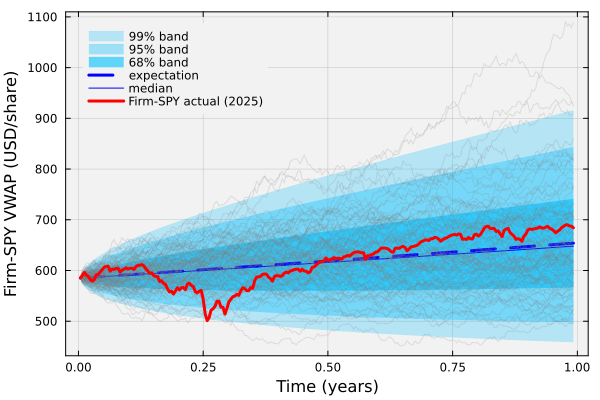

In [14]:
let
    
    # Initialize -
    time_axis = expectation_array[:,1]; # absolute time (years)
    τ = time_axis .- time_axis[1]; # elapsed time from the start of the testing window
    j = findfirst(==(ticker_to_simulate), parameters_df.ticker);
    ĝ = parameters_df[j, :drift]; σ̂ = parameters_df[j, :volatility]; μ̂ = ĝ + 0.5*σ̂^2;
    median_value = Sₒ*exp.((μ̂ - 0.5*σ̂^2)*τ); # lognormal median
    band(z) = (median_value.*exp.(-z*σ̂*sqrt.(τ)), median_value.*exp.(z*σ̂*sqrt.(τ))); # exact quantile band
    (L68,U68) = band(1.0); (L95,U95) = band(1.96); (L99,U99) = band(2.576);
    actual = random_firm_data[1:TSIM, :volume_weighted_average_price];
    @assert length(actual) == length(time_axis) "band and observation lengths differ"

    plot(time_axis, U99, fillrange=L99, c=:deepskyblue1, alpha=0.25, label="99% band", lw=0)
    plot!(time_axis, U95, fillrange=L95, c=:deepskyblue1, alpha=0.35, label="95% band", lw=0)
    plot!(time_axis, U68, fillrange=L68, c=:deepskyblue1, alpha=0.6, label="68% band", lw=0)
    plot!(time_axis, expectation_array[:,2], c=:blue, lw=3, ls=:dash, label="expectation")
    plot!(time_axis, median_value, c=:blue, lw=1, label="median")
    for i ∈ 2:size(X,2) # column 1 is time, columns 2:end are the sample paths
        plot!(X[:,1], X[:,i], c=:gray50, lw=1, alpha=0.2, label="")
    end
    plot!(time_axis, actual, lw=3, c=:red, label="Firm-$(ticker_to_simulate) actual (2025)")
    xlabel!("Time (years)", fontsize=18)
    ylabel!("Firm-$(ticker_to_simulate) VWAP (USD/share)", fontsize=18)
    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent, legend=:topleft);
end

### Check: How often did the observed price stay inside the bands?
Rather than judging by eye, let's count. For the selected firm, we compute the fraction of trading days on which the observed VWAP falls inside the 95% band and inside the 99% band. We score only the forecast days (day 0 is the initial condition and sits inside every band by construction). Under a correct model with correct parameters, each day's coverage probability is 95% (or 99%); across 249 days the observed fractions can differ from those numbers because the days are not independent (a path that leaves the band tends to stay out for a while), so read them as a rough scorecard, not a hypothesis test:

In [15]:
function band_coverage(S₀::Float64, ĝ::Float64, σ̂::Float64, τ::Vector{Float64}, actual::Vector{Float64}; z::Float64 = 1.96)
    μ̂ = ĝ + 0.5*σ̂^2;
    median_value = S₀*exp.((μ̂ - 0.5*σ̂^2)*τ);
    L = median_value.*exp.(-z*σ̂*sqrt.(τ)); U = median_value.*exp.(z*σ̂*sqrt.(τ));
    inside = (actual .>= L) .& (actual .<= U);
    return count(inside[2:end])/length(inside[2:end]) # forecast days only; day 0 is the initial condition
end

function max_abs_z(S₀::Float64, ĝ::Float64, σ̂::Float64, τ::Vector{Float64}, actual::Vector{Float64})
    z = (log.(actual[2:end] ./ S₀) .- ĝ .* τ[2:end]) ./ (σ̂ .* sqrt.(τ[2:end])) # standardized log deviation from the median path
    return maximum(abs.(z))
end

let
    j = findfirst(==(ticker_to_simulate), parameters_df.ticker);
    ĝ = parameters_df[j, :drift]; σ̂ = parameters_df[j, :volatility];
    τ = collect(0:(TSIM-1)) .* Δt; # elapsed time, day 0 to day TSIM-1
    actual = random_firm_data[1:TSIM, :volume_weighted_average_price] |> collect;
    c95 = band_coverage(Sₒ, ĝ, σ̂, τ, actual; z = 1.96);
    c99 = band_coverage(Sₒ, ĝ, σ̂, τ, actual; z = 2.576);
    println("Firm-$(ticker_to_simulate): fraction of 2025 trading days inside the 95% band = $(round(c95, digits=3)); inside the 99% band = $(round(c99, digits=3))")
end

Firm-SPY: fraction of 2025 trading days inside the 95% band = 0.976; inside the 99% band = 0.996


___

## Task 2: Coverage Across Every Firm in the Dataset
One firm is an anecdote. Let's repeat the coverage calculation for every firm that appears in both the parameter table and the 2025 testing set. For each firm we start from its first 2025 VWAP, use its own $\widehat{\bar g}$ and $\hat{\sigma}$ from the training data, and compute the fraction of 2025 forecast days inside the 95% and 99% bands, together with the largest standardized deviation of the observed log price from the model's median path along the year, $\max_{k}\,|\ln(S_{k}/S_{0})-\widehat{\bar g}\,\tau_{k}|/(\hat{\sigma}\sqrt{\tau_{k}})$ (values near 2 are ordinary; values of 4 or more mean the path went somewhere the model considered essentially impossible). We store the results in the `coverage_df::DataFrame` variable, sorted from best to worst:

In [16]:
coverage_df = let
    df = DataFrame(ticker = String[], coverage_95 = Float64[], coverage_99 = Float64[], max_abs_z = Float64[], ĝ = Float64[], σ̂ = Float64[], price_ratio = Float64[]);
    τ = collect(0:(TSIM-1)) .* Δt;
    for row ∈ eachrow(parameters_df)
        ticker = String(row.ticker);
        haskey(dataset, ticker) || continue; # skip firms not in the 2025 testing set
        prices = dataset[ticker][1:TSIM, :volume_weighted_average_price] |> collect;
        S₀ = prices[1];
        c95 = band_coverage(S₀, row.drift, row.volatility, τ, prices; z = 1.96);
        c99 = band_coverage(S₀, row.drift, row.volatility, τ, prices; z = 2.576);
        push!(df, (ticker, c95, c99, max_abs_z(S₀, row.drift, row.volatility, τ, prices), row.drift, row.volatility, prices[end]/S₀));
    end
    sort!(df, :coverage_95, rev = true);
    df
end;
println("Firms scored: $(nrow(coverage_df)); median 95% coverage = $(round(median(coverage_df.coverage_95), digits=3)); fraction of firms with 95% coverage above 0.9: $(round(mean(coverage_df.coverage_95 .> 0.9), digits=3)); fraction below 0.5: $(round(mean(coverage_df.coverage_95 .< 0.5), digits=3))")

Firms scored: 417; median 95% coverage = 1.0; fraction of firms with 95% coverage above 0.9: 0.844; fraction below 0.5: 0.026


So what do we see? Let's look at the distribution of coverage across firms, and at the best and worst cases:

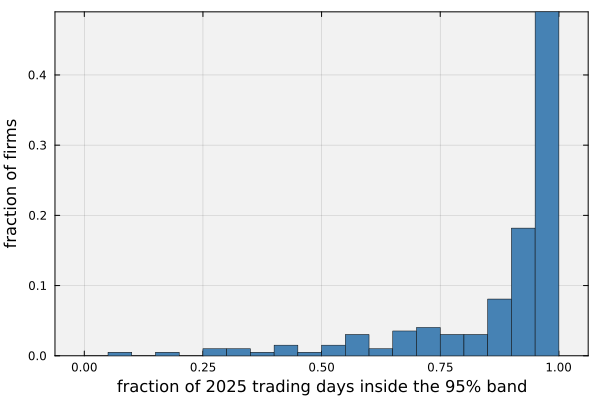

In [17]:
let
    histogram(coverage_df.coverage_95, bins = 0:0.05:1.0, normalize = :probability, c=:steelblue, lw=0.5, label="",
        xlabel = "fraction of 2025 trading days inside the 95% band", ylabel = "fraction of firms")
    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);
end

The best and worst five firms by 95% coverage, with the maximum standardized deviation, the training-period parameters, and the 2025 price ratio (last VWAP over first). The terminal ratio alone is only a hint (coverage scores the whole path, and a firm can leave the band in March and return by December); the maximum standardized deviation is the direct measure of how far outside the model's range the year went:

In [18]:
let
    cols = [:ticker, :coverage_95, :max_abs_z, :ĝ, :σ̂, :price_ratio];
    best = first(coverage_df, 5)[:, cols]; worst = last(coverage_df, 5)[:, cols];
    println("Best five (95% coverage):"); pretty_table(best; formatters = [fmt__printf("%.3f", [2,3,4,5,6])])
    println("Worst five (95% coverage):"); pretty_table(worst; formatters = [fmt__printf("%.3f", [2,3,4,5,6])])
end

Best five (95% coverage):
┌────────┬─────────────┬───────────┬─────────┬─────────┬─────────────┐
│ ticker │ coverage_95 │ max_abs_z │       ĝ │       σ̂ │ price_ratio │
│ String │     Float64 │   Float64 │ Float64 │ Float64 │     Float64 │
├────────┼─────────────┼───────────┼─────────┼─────────┼─────────────┤
│   ABBV │       1.000 │     1.687 │   0.116 │   0.243 │       1.278 │
│    ADM │       1.000 │     1.626 │   0.056 │   0.233 │       1.143 │
│    ADP │       1.000 │     1.396 │   0.129 │   0.203 │       0.888 │
│   ADSK │       1.000 │     1.537 │   0.176 │   0.313 │       1.008 │
│    AEE │       1.000 │     1.887 │   0.080 │   0.186 │       1.123 │
└────────┴─────────────┴───────────┴─────────┴─────────┴─────────────┘
Worst five (95% coverage):
┌────────┬─────────────┬───────────┬─────────┬─────────┬─────────────┐
│ ticker │ coverage_95 │ max_abs_z │       ĝ │       σ̂ │ price_ratio │
│ String │     Float64 │   Float64 │ Float64 │ Float64 │     Float64 │
├────────┼────────────

Two things follow. First, the model is not useless out of sample: for a large fraction of firms the observed 2025 path stayed inside the 95% band on most days, which is what a reasonable, if imperfect, model of price uncertainty should deliver. Second, the failures are large: the worst cases wandered many standard deviations from the model's median path, which is consistent with the training-period drift and volatility no longer describing 2025 (parameter instability), or with the model missing something (heavy tails, jumps), and one realized path cannot tell those apart. What it can tell us is that a constant-parameter GBM offers no way to see such a year coming; models that let the parameters vary in time are a topic for later in the course.
___

## Summary
In this example, we used GBM parameters estimated from 2014 to 2024 to predict prices throughout 2025, drew the model's exact prediction bands, and measured how often the observed prices stayed inside them, for one firm and for every firm in the dataset.

> __Key Takeaways:__
>
> * **Out-of-sample testing is the honest test:** Parameters estimated on the training data are applied to prices the model never saw; the exact one-step transition simulates the paths, and the lognormal quantile bands give the model's own statement of uncertainty at each future date.
>
> * **Coverage is measured, not asserted:** The fraction of days inside the 95% band, computed for every firm, shows that a constant-parameter GBM brackets the observed path for most firms most of the time while failing badly for a minority.
>
> * **The failures are large and informative:** The worst-covered firms wandered many standard deviations from the model's median path, consistent with parameters that no longer describe the year or with features the model lacks; a model with constant parameters cannot anticipate either.

Out-of-sample evaluation therefore belongs in every modeling workflow in this course: it reveals whether fitted parameters remain useful after calibration, and it is where the case for time-varying models begins.
___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___